[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework7.ipynb)

# Exercise 1
We will derive ...


**Scenario A**

Let $f(\lambda) = \sum\limits_{i = 1}^{m + k} (-y_i \log(\frac{1}{1 + e^{-\lambda}}) -(1 - y_i)\log(1 - \frac{1}{1 + e^{-\lambda}})))$. To obtain $\lambda^*$, which minimizes this expression, we calculate the derivative of *f* with respect to $\lambda$ and set it to zero.

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (-y_i (1 + e^{-\lambda})(\frac{1}{1 + e^{-\lambda}})^2 + (1-y_i)(\frac{1 + e^{-\lambda}}{e^{-\lambda}})(\frac{1}{1 + e^{-\lambda}})^2)$$

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (-\frac{y_i}{1 + e^{-\lambda}} + \frac{1-y_i}{e^{-\lambda}(1 + e^{-\lambda})})$$

Expressions in the denominators does not depend on $i$, so we sum only over $y$'s. From the problem we know, that $\sum\limits_{i = 1}^{m + k} y_i = m$, so we use this fact and obtain:

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} -\frac{y_i}{1 + e^{-\lambda}} + \sum\limits_{i = 1}^{m + k}\frac{1}{e^{-\lambda}(1 + e^{-\lambda})}  - \sum\limits_{i = 1}^{m + k} \frac{y_i}{e^{-\lambda}(1 + e^{-\lambda})} $$

$$ f'(\lambda)  = -\frac{m}{1 + e^{-\lambda}} + \frac{m + k}{e^{-\lambda}(1 + e^{-\lambda})} - \frac{m}{e^{-\lambda}(1 + e^{-\lambda})} $$

To calculate minimum of $f(\lambda)$ we set the derivative to 0:

$$-\frac{m}{1 + e^{-\lambda}} + \frac{m + k}{e^{-\lambda}(1 + e^{-\lambda})} - \frac{m}{e^{-\lambda}(1 + e^{-\lambda})} = 0$$

$$-me^{-\lambda} +m + k - m = 0$$

$$e^{-\lambda} = \frac{k}{m}$$

$$\lambda = \log(\frac{m}{k})$$

We observe that $-f(\lambda)$ is convex combination of concave functions, so it is also concave. From then we conclude that $f(\lambda)$ is convex function, so its derivative $f'(\lambda)$ is strictly positive and the only extremum of $f(\lambda)$ is global minimum, so

 $$\operatorname{argmin}_{\lambda} f(\lambda) =\log(\frac{m}{k}).$$

This constant represents logarithm of the ratio between number of ones and the number of zeros in the labels $y_i$.

**Scenario B**

We try to do the same as in *Scenario A*.

Let $f(\lambda) = \sum\limits_{i = 1}^{m + k} (-y_i \log(\frac{1}{1 + e^{-(\lambda + f_i)}}) -(1 - y_i)\log(1 - \frac{1}{1 + e^{-(\lambda + f_i)}})))$. To obtain $\lambda^*$, which minimizes this expression, we calculate the derivative of *f* with respect to $\lambda$ and set it to zero.

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (-y_i (1 + e^{-(\lambda + f_i)})(\frac{1}{1 + e^{-(\lambda + f_i)}})^2 + (1-y_i)(\frac{1 + e^{-(\lambda + f_i)}}{e^{-(\lambda + f_i)}})(\frac{1}{1 + e^{-(\lambda + f_i)}})^2)$$

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (-\frac{y_i}{1 + e^{-(\lambda + f_i)}} + \frac{1-y_i}{e^{-(\lambda + f_i)}(1 + e^{-(\lambda + f_i)})})$$

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (\frac{-y_ie^{-(\lambda + f_i)}+1-y_i}{e^{-(\lambda + f_i)}(1 + e^{-(\lambda + f_i)})} )$$


# Exercise 2


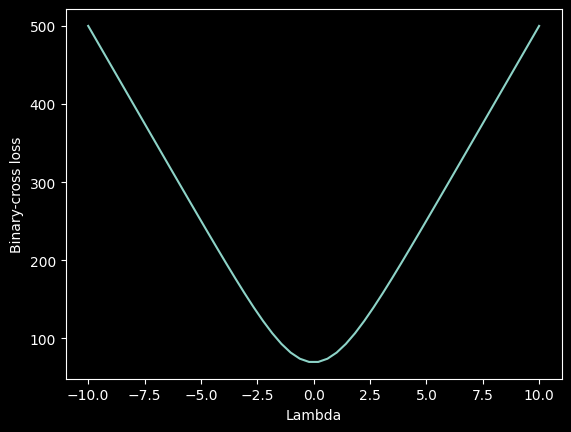

In [29]:
import numpy as np
import matplotlib.pyplot as plt

m = 50
k = 50
n = m + k

labels = np.array(m * [1] + k * [0], dtype = float)
np.random.shuffle(labels)

def binary_cross_entropy(args, labels):
    losses = []
    for arg in args:
        p = 1 / (1 + np.exp(-arg))
        loss = -1 * np.sum(labels * np.log(p) + (1.0 - labels) * np.log(1.0 - p))
        losses.append(loss)
    return losses

x = np.linspace(-10, 10, 50)
y = binary_cross_entropy(x, labels)
plt.xlabel("Lambda")
plt.ylabel("Binary-cross loss")
plt.title("")

plt.plot(x, y)


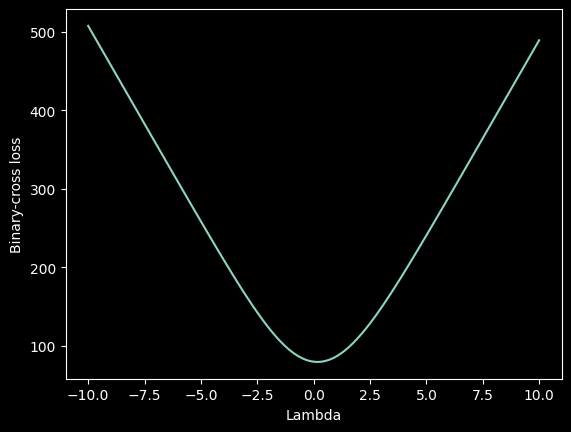

In [44]:
predictions = np.random.normal(loc = 0, scale = 1, size = n)
def binary_cross_predictions(predictions, lambdas, labels):
    result = []
    for arg in lambdas:
        p = 1 / (1 + np.exp(-arg - predictions))
        result.append(np.sum(-1*labels * np.log(p) - (1 - labels) * np.log(1 - p)))
    return result
x = np.linspace(-10, 10, 100)
y = binary_cross_predictions(predictions, x, labels)
plt.xlabel("Lambda")
plt.xlabel("Lambda")
plt.ylabel("Binary-cross loss")
plt.title("")

plt.plot(x, y)